<a href="https://colab.research.google.com/github/Omsai-2000/Exploratory-Data-Analysis/blob/main/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("/content/diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
X=df.drop('Outcome', axis=1)
Y=df['Outcome']

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [7]:
from sklearn.ensemble import RandomForestClassifier

In [8]:
rf=RandomForestClassifier(n_estimators=100)

In [9]:
rf.fit(X_train, Y_train)

RandomForestClassifier()

In [10]:
rf.feature_importances_

array([0.07951802, 0.25148517, 0.0904467 , 0.07042129, 0.07797824,
       0.16061259, 0.12216425, 0.14737373])

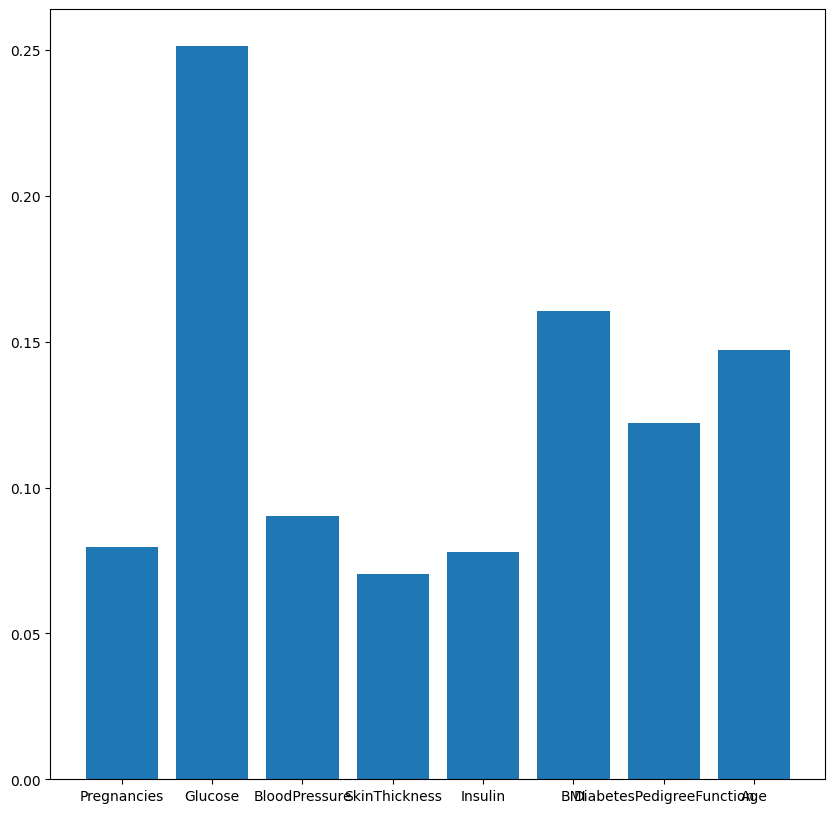

In [14]:
import matplotlib.pyplot as plt
fig=plt.figure(figsize=(10,10))
plt.bar(X_train.columns, rf.feature_importances_)
plt.show()

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

In [16]:
Y_pred=rf.predict(X_test)
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.81      0.80      0.80        99
           1       0.64      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.72      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



In [19]:
best_score=0
scores=[]
for n in [25, 50, 75, 100, 125, 150, 175, 200]:
  for d in [4,5,6,7,8]:
    rf=RandomForestClassifier(n_estimators=n, max_depth=d)
    rf.fit(X_train, Y_train)
    Y_pred=rf.predict(X_test)
    score=rf.score(X_test, Y_pred)
    scores.append(score)
    if score>best_score:
      best_score=score
      best_n=n
      best_d=d
print(best_score, best_n, best_d)

1.0 25 4
